# ECOv003 JET Accuracy Analysis with ECOv002 Cal-Val and SOBOL Sensitivity

This notebook performs accuracy assessment, Monte Carlo sensitivity analysis, and Sobol sensitivity analysis of the JET ensemble using ECOSTRESS Collection 2 Cal-Val data.

## Import Required Libraries and Functions

This cell imports all necessary libraries and functions for data processing, model execution, statistical analysis, plotting, and sensitivity analyses (Monte Carlo and Sobol).

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname('__file__'), '..')))
from typing import Callable
from os import makedirs
from os.path import join

import numpy as np
import pandas as pd
from scipy.stats import mstats
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.metrics import r2_score, mean_squared_error

# Custom JET and Net Radiation modules
from verma_net_radiation import verma_net_radiation_table
from JET3 import process_JET_table, load_ECOv002_calval_JET_inputs

# Monte Carlo Sensitivity analysis imports
from monte_carlo_sensitivity import (
    perturbed_run, 
    sensitivity_analysis, 
    divide_absolute_by_unperturbed, 
    sensitivity_magnitude_barchart
)

# Sobol analysis imports
from SALib.sample import saltelli
from SALib.analyze import sobol

## Configuration Options & Model Setup

Set configuration options for the notebook, variables, and physical bounds.

In [2]:
# Configuration: Set to True to save plots to files, False to only display them
SAVE_PLOTS = False

input_variables = [
    'ST_C', 'NDVI', 'albedo', 'Ta_C', 'RH', 
    'AOT', 'COT', 'vapor_gccm', 'ozone_cm', 
    'elevation_m', 'canopy_height_meters'
]

output_variables = [
    'Rn_Wm2',
    'ET_daylight_kg',
    'GPP_inst_g_m2_s'
]

# Per-variable physical bounds to keep perturbations realistic
input_min = {
    'ST_C': 0.0, 'NDVI': 0.05, 'albedo': 0.0, 'Ta_C': 0.0,
    'RH': 0.0, 'AOT': 0.0, 'COT': 0.0, 'vapor_gccm': 0.0,
    'ozone_cm': 0.0, 'elevation_m': 0.0, 'canopy_height_meters': 0.0,
}

input_max = {
    'ST_C': 50.0,
    'NDVI': 1,
    'albedo': 1,
}

forward_process = process_JET_table
model_name = 'JET'
normalization_function = divide_absolute_by_unperturbed

## Load, Filter, and Process Data

Loads the ECOSTRESS Cal-Val inputs, applies bounds, and runs the baseline model.

In [3]:
input_df = load_ECOv002_calval_JET_inputs()

# Apply lower and upper bounds from configuration dictionaries
mask = pd.Series(True, index=input_df.index)
for var, min_val in input_min.items():
    if var in input_df.columns:
        mask &= input_df[var] >= min_val
for var, max_val in input_max.items():
    if var in input_df.columns:
        mask &= input_df[var] <= max_val

input_df = input_df[mask]
input_df = input_df.dropna()

# Process baseline data through the model
processed = forward_process(input_df)
processed.head()

[2026-08-11 12:11:13 INFO] starting JET table processing
[2026-08-11 12:11:13 INFO] started extracting geometry from JET input table
[2026-08-11 12:11:13 INFO] completed extracting geometry from JET input table (0.003 seconds)
[2026-08-11 12:11:13 INFO] started extracting time from JET input table
[2026-08-11 12:11:13 INFO] completed extracting time from JET input table (0.001 seconds)
[2026-08-11 12:11:13 INFO] running Forest Light Environmental Simulator
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
[2026-08-11 12:11:14 INFO] completed processing FLiES-ANN in 0.21 seconds
[2026-08-11 12:11:14 INFO] variable PAR_albedo min: 0.007 mean: 0.055 max: 0.193 nan: 0.00% (nan)
[2026-08-11 12:11:14 INFO] variable NIR_albedo min: 0.066 mean: 0.162 max: 0.530 nan: 0.00% (nan)
[2026-08-11 12:11:14 INFO] variable PAR_direct_Wm2 min: 7.148 mean: 269.735 max: 442.463 nan: 0.00% (nan)
[2026-08-11 12:11:14 INFO] variable SWin_FLiES_ANN min: 163.676 mean: 716.916 max: 1095.605 nan: 0.00% (nan)
[2026-08-11 12:1

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Use

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,G_PMJPL_Wm2,G_Wm2,LE_instantaneous_Wm2,LE_Wm2,H_Wm2,ET_daylight_kg,ET_uncertainty,GPP_inst_g_m2_s,ET_canopy_inst_kg_m2_s,WUE
15,15,US-xAB,ENF,Csb,141.635670,168.24043,402.81810,159.71700,139.016083,107.183200,...,24.219544,24.219544,203.764376,203.764376,248.713696,2.900053,0.510811,0.000151,0.000058,2.606544
17,17,US-xAB,ENF,Csb,1.881266,163.94730,301.40400,179.13661,131.273636,106.525215,...,13.772918,13.772918,163.144742,163.144742,194.438550,2.854526,1.085331,0.000108,0.000034,3.174119
18,18,US-xAB,ENF,Csb,3.135606,246.87700,614.51480,405.50497,366.056641,222.890230,...,33.327171,33.327171,342.565013,342.565013,348.501129,4.442026,0.971980,0.000291,0.000122,2.390822
19,19,US-xAB,ENF,Csb,311.482820,290.73126,672.27510,478.82382,439.821228,153.787670,...,42.878466,42.878466,403.011097,403.011097,366.186555,4.947329,1.401781,0.000294,0.000211,1.388074
20,20,US-xAB,ENF,Csb,51.920338,95.28810,116.67136,73.20884,232.693512,24.038680,...,2.903705,2.903705,112.556235,112.556235,52.720986,2.991218,0.730132,0.000095,0.000015,6.238326


## Accuracy Comparison Analysis

Examining the accuracy of model estimates compared to ground data.

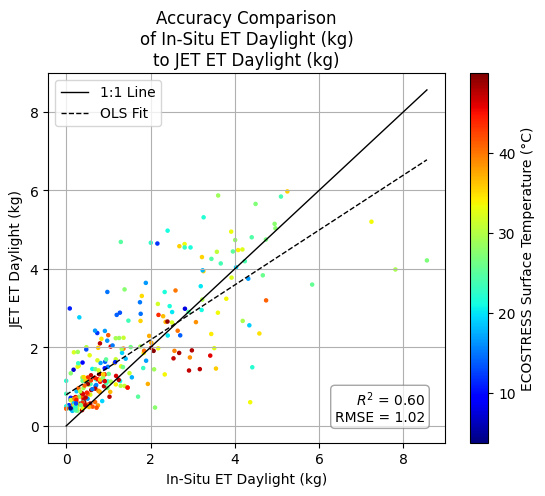

In [4]:
def generate_accuracy_plot(df, x_variable, y_variable, output_variable, model_name, color_col='ST_C', cbar_label='ECOSTRESS Surface Temperature (°C)', save_plots=False):
    """
    Generates and optionally saves a scatter plot comparing in-situ data to model output,
    including a 1:1 line, OLS regression fit, R-squared, and RMSE annotations.
    """
    valid_data = df[[x_variable, y_variable, color_col]].dropna()
    
    # Create the scatter plot
    sc = plt.scatter(
        x=valid_data[x_variable],
        y=valid_data[y_variable],
        c=valid_data[color_col],
        cmap='jet',
        s=5
    )

    # Get the actual data bounds to ensure lines span the whole plot
    x_min, x_max = valid_data[x_variable].min(), valid_data[x_variable].max()
    y_min, y_max = valid_data[y_variable].min(), valid_data[y_variable].max()
    
    # Calculate a square bounding box for the 1:1 line
    plot_min = min(x_min, y_min)
    plot_max = max(x_max, y_max)

    plt.plot([plot_min, plot_max], [plot_min, plot_max], color='black', linestyle='-', linewidth=1, label='1:1 Line')

    # Add OLS regression line
    coefs = np.polyfit(valid_data[x_variable], valid_data[y_variable], 1)
    ols_x = np.array([x_min, x_max])
    ols_y = coefs[0] * ols_x + coefs[1]
    plt.plot(ols_x, ols_y, color='black', linestyle='--', linewidth=1, label='OLS Fit')

    # R-squared of the linear fit
    y_true_for_r2 = valid_data[y_variable]
    y_pred_from_ols = coefs[0] * valid_data[x_variable] + coefs[1]
    r2 = r2_score(y_true_for_r2, y_pred_from_ols)
    
    # RMSE between the model and in-situ data
    rmse = np.sqrt(mean_squared_error(valid_data[x_variable], valid_data[y_variable]))

    # Annotate R-squared and RMSE on plot in lower right corner
    plt.annotate(f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.2f}",
                xy=(0.95, 0.05), xycoords='axes fraction',
                ha='right', va='bottom',
                fontsize=10,
                bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.7))

    # Format the plot
    plt.grid(True, zorder=0)
    plt.xlabel(f"In-Situ {output_variable}")
    plt.ylabel(f"{model_name} {output_variable}")
    plt.title(f"Accuracy Comparison\nof In-Situ {output_variable}\nto {model_name} {output_variable}")
    
    plt.colorbar(sc, label=cbar_label)
    plt.legend(loc='upper left')
    
    # Save if requested
    if save_plots:
        plt.savefig(f"Accuracy Comparison of In-Situ {output_variable} to {model_name} {output_variable}.jpeg", format='jpeg', bbox_inches='tight')
        plt.savefig(f"Accuracy Comparison of In-Situ {output_variable} to {model_name} {output_variable}.svg", format='svg', bbox_inches='tight')
    
    plt.show()

# Execute Example for ET
generate_accuracy_plot(
    df=processed, 
    x_variable='insitu_ET_daylight_kg', # Replace with exact column name if different
    y_variable='ET_daylight_kg', 
    output_variable='ET Daylight (kg)', 
    model_name=model_name,
    save_plots=SAVE_PLOTS
)

## Monte Carlo Sensitivity Analysis

Utilizes the pre-imported `monte_carlo_sensitivity` functions.

In [5]:
# Perform the Monte Carlo sensitivity analysis
mc_results = sensitivity_analysis(
    input_df=input_df,
    forward_process=forward_process,
    input_variables=input_variables,
    output_variables=output_variables,
    # Note: Removed `iterations=num_iterations` argument to resolve TypeError.
    input_min=input_min,
    input_max=input_max,
    normalization_function=normalization_function
)

# Visualize magnitude for a specific target output (e.g., Latent Heat Flux / ET)
sensitivity_magnitude_barchart(
    # Removed `results_df` argument keyword to fix TypeError
    mc_results,
    target_output='ET_daylight_kg',
    title='Monte Carlo Sensitivity Magnitude for ET Daylight'
)

[2026-08-11 12:11:14 INFO] starting JET table processing
[2026-08-11 12:11:14 INFO] started extracting geometry from JET input table
[2026-08-11 12:11:14 INFO] completed extracting geometry from JET input table (0.003 seconds)
[2026-08-11 12:11:14 INFO] started extracting time from JET input table
[2026-08-11 12:11:14 INFO] completed extracting time from JET input table (0.001 seconds)
[2026-08-11 12:11:14 INFO] running Forest Light Environmental Simulator
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
[2026-08-11 12:11:14 INFO] completed processing FLiES-ANN in 0.19 seconds
[2026-08-11 12:11:14 INFO] variable PAR_albedo min: 0.007 mean: 0.055 max: 0.193 nan: 0.00% (nan)
[2026-08-11 12:11:14 INFO] variable NIR_albedo min: 0.066 mean: 0.162 max: 0.530 nan: 0.00% (nan)
[2026-08-11 12:11:14 INFO] variable PAR_direct_Wm2 min: 7.148 mean: 269.735 max: 442.463 nan: 0.00% (nan)
[2026-08-11 12:11:14 INFO] variable SWin_FLiES_ANN min: 163.676 mean: 716.916 max: 1095.605 nan: 0.00% (nan)
[2026-08-11 12:1

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')


[2026-08-11 12:11:14 INFO] * 0.0813326167352959: 32
[2026-08-11 12:11:14 INFO] * 0.0827622704609846: 2
[2026-08-11 12:11:14 INFO] * 0.0852152226652387: 62
[2026-08-11 12:11:14 INFO] * 0.0894272443356804: 10
[2026-08-11 12:11:14 INFO] * 0.0900000035762786: 41
[2026-08-11 12:11:14 INFO] * 0.0900000035762787: 16
[2026-08-11 12:11:14 INFO] variable kn (float64) with [0.41       0.41       0.41       0.44997853 0.49286811 0.56645664
 0.69281721 0.70999998 0.70999998] unique values
[2026-08-11 12:11:14 INFO] * 0.4099999964237212: 27
[2026-08-11 12:11:14 INFO] * 0.4099999964237213: 76
[2026-08-11 12:11:14 INFO] * 0.4099999964237214: 4
[2026-08-11 12:11:14 INFO] * 0.449978528297716: 32
[2026-08-11 12:11:14 INFO] * 0.4928681145041901: 2
[2026-08-11 12:11:14 INFO] * 0.5664566367696335: 62
[2026-08-11 12:11:14 INFO] * 0.6928172115661085: 10
[2026-08-11 12:11:14 INFO] * 0.7099999785423278: 14
[2026-08-11 12:11:14 INFO] * 0.7099999785423279: 43
[2026-08-11 12:11:14 INFO] variable peakVCmax_C3_μmolm

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Use

[2026-08-11 12:11:15 INFO] starting JET table processing
[2026-08-11 12:11:18 INFO] started extracting geometry from JET input table
[2026-08-11 12:11:21 INFO] completed extracting geometry from JET input table (2.668 seconds)
[2026-08-11 12:11:21 INFO] started extracting time from JET input table
[2026-08-11 12:11:21 INFO] completed extracting time from JET input table (0.119 seconds)
[2026-08-11 12:11:21 INFO] running Forest Light Environmental Simulator


...

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')


[2026-08-11 12:12:11 INFO] completed daylight ET upscaling (elapsed: 7.38 seconds)
[2026-08-11 12:12:11 INFO] PT-JPL-SM model run complete (elapsed: 7.60 seconds)
[2026-08-11 12:12:11 INFO] completed processing PT-JPL-SM in 7.60 seconds
[2026-08-11 12:12:11 INFO] variable LE_PTJPLSM_Wm2 min: 0.000 mean: 192.290 max: 922.227 nan: 1.50% (nan)
[2026-08-11 12:12:11 INFO] variable ET_daylight_PTJPLSM_kg min: 0.000 mean: 2.637 max: 12.394 nan: 1.50% (nan)
[2026-08-11 12:12:11 INFO] variable G_PTJPLSM min: 0.000 mean: 68.305 max: 216.225 nan: 1.50% (nan)
[2026-08-11 12:12:11 INFO] variable EF_PTJPLSM min: 0.000 mean: 0.423 max: 1.108 nan: 1.50% (nan)
[2026-08-11 12:12:11 INFO] variable LE_canopy_PTJPLSM_Wm2 min: 0.000 mean: 129.307 max: 790.602 nan: 1.50% (nan)
[2026-08-11 12:12:11 INFO] variable LE_canopy_fraction_PTJPLSM min: 0.000 mean: 0.743 max: 1.000 nan: 1.52% (nan)
[2026-08-11 12:12:11 INFO] variable LE_soil_PTJPLSM_Wm2 min: 0.000 mean: 55.269 max: 594.144 nan: 1.50% (nan)
[2026-08-11

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')


[2026-08-11 12:12:19 INFO] completed daylight ET upscaling (PMJPL)
[2026-08-11 12:12:19 INFO] completed processing PM-JPL in 7.75 seconds
[2026-08-11 12:12:19 INFO] variable LE_PMJPL_Wm2 min: 0.000 mean: 97.147 max: 780.303 nan: 1.50% (nan)
[2026-08-11 12:12:19 INFO] variable ET_daylight_PMJPL_kg min: 0.000 mean: 1.362 max: 9.001 nan: 1.50% (nan)
[2026-08-11 12:12:19 INFO] variable G_PMJPL_Wm2 min: 0.000 mean: 68.305 max: 216.225 nan: 1.50% (nan)
[2026-08-11 12:12:19 INFO] variable ET_daylight_kg min: 0.000 mean: 1.838 max: 9.997 nan: 0.00% (nan)
[2026-08-11 12:12:20 INFO] JET table processing complete (64.160 seconds)


TypeError: sensitivity_magnitude_barchart() got an unexpected keyword argument 'target_output'

## Sobol Sensitivity Analysis

The Sobol analysis decomposes variance into First-Order (S1) and Total-Order (ST) effects to measure direct and interactive sensitivities.

In [ ]:
# 1. Define the SALib problem dictionary based on configs
problem = {
    'num_vars': len(input_variables),
    'names': input_variables,
    'bounds': [
        [input_min.get(var, 0.0), input_max.get(var, 100.0)] # Uses config bounds, defaults to 100 if no max specified
        for var in input_variables
    ]
}

# 2. Generate Sobol samples
# N=1024 generates N * (2D + 2) samples
param_samples = saltelli.sample(problem, 1024)

# 3. Create a wrapper to map generated SALib parameters to the model's input format
def evaluate_model_for_sobol(params_array, base_df):
    results = []
    # Create a base template row from the means of the input data
    template_row = base_df.mean().to_dict()
    
    for params in params_array:
        # Update template with sampled parameters
        for idx, var in enumerate(input_variables):
            template_row[var] = params[idx]
        
        temp_df = pd.DataFrame([template_row])
        out = forward_process(temp_df)
        
        # Target ET_daylight_kg for the variance decomposition
        results.append(out['ET_daylight_kg'].iloc[0]) 
    return np.array(results)

# 4. Run the model on the generated samples
Y_sobol = evaluate_model_for_sobol(param_samples, input_df)

# 5. Perform the Sobol Analysis
sobol_indices = sobol.analyze(problem, Y_sobol, print_to_console=False)

# 6. Plot the Sobol Results
sobol_df = pd.DataFrame({
    'Variable': input_variables,
    'S1': sobol_indices['S1'],
    'ST': sobol_indices['ST']
}).set_index('Variable').sort_values(by='ST', ascending=False)

sobol_df.plot(kind='bar', figsize=(10, 6))
plt.title("Sobol Sensitivity Indices for JET Ensemble (ET_daylight_kg)")
plt.ylabel("Sensitivity Index")
plt.tight_layout()
if SAVE_PLOTS:
    plt.savefig("Sobol_Sensitivity_Analysis.jpeg", format="jpeg")
plt.show()